# t-distributed Stochastic Neighbor Embedding (tSNE)

### What Is t-SNE?

t-SNE is a <span style="color:#ff7f0e">**non-linear**</span> dimensionality-reduction technique that turns very high-dimensional data into a 2-D or 3-D map in which points that were close together in the original space stay close, while distant points move apart. 

The idea: preserve <span style="color:#2ca02c">**local neighborhoods**</span> by matching pair-wise *similarity probabilities* in the high-dimensional space with those in the low-dimensional map, then minimizing the difference between the two probability distributions.

---

### How It Works

Conceptual algorithm:

1. <span style="color:#1f77b4">**Compute similarities**</span>:
   *For every pair of samples* convert Euclidean distances into conditional probabilities

   $$
   p_{j|i}=\frac{\exp(-\lVert x_i-x_j\rVert^{2}/2\sigma_i^{2})}{\sum_{k\neq i}\exp(-\lVert x_i-x_k\rVert^{2}/2\sigma_i^{2})},
   $$

   where the bandwidth $\sigma_i$ is chosen so each point has a user-defined <span style="color:#ff7f0e">**perplexity**</span> ($\approx$ effective number of neighbors).

2. <span style="color:#1f77b4">**Symmetrize**</span>: to get joint probabilities $p_{ij}$.

3. **Initialize** low-dimensional points $y_i$ at random.

4. <span style="color:#1f77b4">**Model similarities**</span> in the map with a heavy-tailed Student-t distribution with one degree of freedom

   $$
   q_{ij}=\frac{(1+\lVert y_i-y_j\rVert^{2})^{-1}}{\sum_{k\neq l}(1+\lVert y_k-y_l\rVert^{2})^{-1}}.
   $$

5. <span style="color:#2ca02c">**Minimize**</span> the Kullback–Leibler divergence

   $$
   \text{KL}(P\|Q)=\sum_{i\neq j} p_{ij}\log\frac{p_{ij}}{q_{ij}}
   $$

   via gradient descent, often starting with an <span style="color:#ff7f0e">**early-exaggeration**</span> phase that temporarily multiplies all $p_{ij}$ to tease clusters apart.

6. **Iterate** until the map stabilizes (a few hundred to a few thousand steps).

---

### Pros and Cons

✅ Uncovers **non-linear structure**   
✅ **Few knobs** to tune (perplexity, learning-rate).  
✅ Works on images, word embeddings, gene-expression data, etc.  

❌ Axes have **no quantitative meaning**; distances across points are unreliable.  
❌ **Non-convex**: not ideal for strict reproducibility.  
❌ Computational cost grows quickly 

---

### Key Hyper-parameters

| Symbol in `sklearn`  | Meaning                             | Typical starter value |
| -------------------- | ----------------------------------- | --------------------- |
| `perplexity`         | Effective neighborhood size         | 30 (range 5 – 50)     |
| `learning_rate`      | Gradient-descent step size          | 200                   |
| `n_iter`             | Total iterations                    | 1000                  |
| `early_exaggeration` | Separation boost in first 250 steps | 12                    |

---

In [1]:
# --- Step 0 (setup): create a small Spotify-like numeric data set ---------
# The original 2025 notebook used a large Spotify CSV. For the upload package,
# we generate a reproducible stand-in so the notebook is self-contained.
import pandas as pd
import numpy as np

_rng = np.random.default_rng(42)
_n = 5_000
_genre = _rng.integers(0, 3, _n)                    # three latent audio profiles
_profiles = np.array([
    [0.8, 0.9, -5.0, 0.10, 0.10, 0.05, 0.20, 0.75, 125.0, 210_000],
    [0.4, 0.3, -14.0, 0.04, 0.75, 0.25, 0.15, 0.35,  85.0, 240_000],
    [0.6, 0.6, -8.0, 0.18, 0.30, 0.10, 0.35, 0.55, 105.0, 195_000],
])
_scales = np.array([0.12, 0.12, 2.0, 0.04, 0.15, 0.10, 0.08, 0.15, 12.0, 25_000])
_feat = _profiles[_genre] + _rng.normal(0, _scales, size=(_n, 10))

num_cols = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness",
    "valence", "tempo", "duration_ms"
]
spotify = pd.DataFrame(_feat, columns=num_cols)
for col in ["danceability", "energy", "speechiness", "acousticness", "instrumentalness", "liveness", "valence"]:
    spotify[col] = spotify[col].clip(0, 1)
spotify["tempo"] = spotify["tempo"].clip(45, 210)
spotify["duration_ms"] = spotify["duration_ms"].clip(60_000, 420_000)
spotify["popularity"] = (30 + 20 * _genre + _rng.normal(0, 8, _n)).clip(0, 100)

# Keep just numeric audio columns. X is n x p: 5000 tracks, 10 numeric features.
X = spotify[num_cols].dropna()


In [2]:
# standardise input
# Prep for Step 1: standardize the features so no single column (e.g., tempo,
# duration_ms) dominates the pairwise distances that Step 1 converts into
# neighbor probabilities.
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
X_std = StandardScaler().fit_transform(X)
seed=42
# All six steps of the conceptual algorithm run inside TSNE():
#   Steps 1-2 (similarities + symmetrize): pairwise distances -> joint
#       neighbor probabilities p_ij; perplexity=30 sets each point's
#       bandwidth sigma_i (~30 effective neighbors).
#   Step 3 (initialize): init="pca" replaces the random start with a PCA
#       layout -- a more stable, more reproducible initialization.
#   Steps 4-5 (heavy-tailed q_ij + minimize KL): gradient descent in 2-D;
#       learning_rate="auto" picks the step size.
#   Step 6 (iterate): runs for the default 1000 iterations.
#   random_state=seed pins the stochastic parts -- without it, every run
#       gives a different map.
tsne = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate="auto",
        init="pca",
        random_state=seed
    ).fit_transform(X_std)

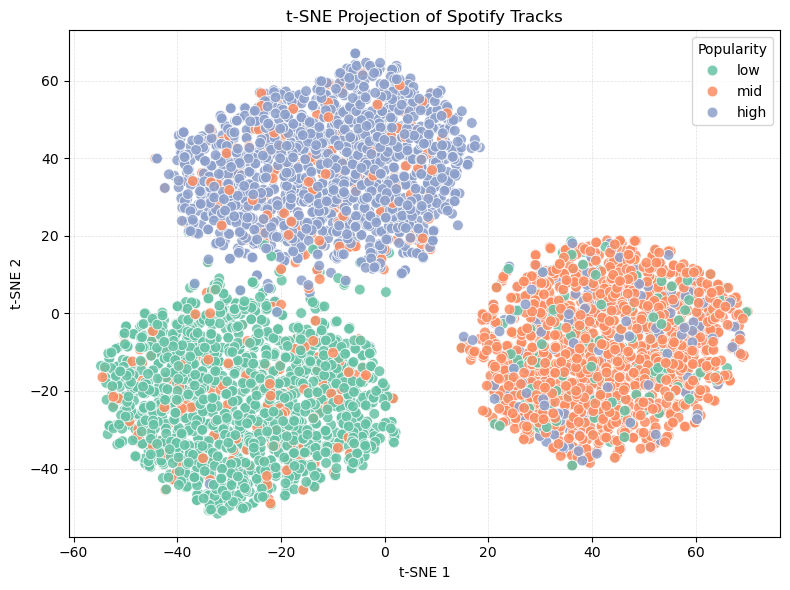

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Read off the embedding (the end of Step 6): each track is now a 2-D point.
# Color by popularity terciles -- a column t-SNE never saw -- to ask whether
# tracks with similar audio profiles also share popularity.
# bin popularity (0-100) into terciles
pop = spotify.loc[X.index, "popularity"].fillna(0)
colour_label = pd.qcut(pop, 3, labels=["low", "mid", "high"])

df_tsne = pd.DataFrame(tsne, columns=["TSNE1", "TSNE2"])
df_tsne["label"] = colour_label.values          

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_tsne,
    x="TSNE1",
    y="TSNE2",
    hue="label",
    palette="Set2",
    s=60,          # marker size
    alpha=0.85
)

plt.title("t-SNE Projection of Spotify Tracks")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Popularity", loc="best", frameon=True)
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)
plt.tight_layout()
plt.show()
